In [2]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

In [108]:
class MixedNaiveBayes:
    def __init__(self,data=None, X=None, Y=None, alpha=1.0):
        self.data = data
        self.X = X
        self.Y = Y
        self.alpha = alpha
        self.classes = data[Y].unique()

    def detect_feature_types(self):
        types = {}
        for feature in self.X:
            nunique = self.data[feature].nunique()

            if nunique == 2:
                types[feature] = "binary"
            elif nunique <= 20:
                types[feature] = "categorical"
            else:
                types[feature] = "continuous"

        return types

    def compute_priors(self):
        priors = {}
        total = len(self.data)

        for c in self.classes:
            priors[c] = (self.data[self.data[self.Y] == c].shape[0]) / total

        return priors

    def fit(self):
        self.feature_types = self.detect_feature_types()
        self.priors = self.compute_priors()

        self.cond_probs = {}
        self.gaussians = {}
        self.category_values = {}

        # Store all possible values for discrete features
        for feature in self.X:
            ftype = self.feature_types[feature]
            if ftype in ("binary", "categorical"):
                self.category_values[feature] = self.data[feature].unique().tolist()

        for c in self.classes:
            subset = self.data[self.data[self.Y] == c]

            self.cond_probs[c] = {}
            self.gaussians[c] = {}

            for feature in self.X:
                ftype = self.feature_types[feature]

                if ftype in ("binary", "categorical"):
                    values = self.category_values[feature]
                    counts = subset[feature].value_counts().to_dict()

                    total_count = len(subset)
                    K = len(values)
                    alpha = self.alpha
                    # add laplace smoothing to prevent zero conditional probability:
                    self.cond_probs[c][feature] = {
                        v: (counts.get(v, 0) + alpha) / (total_count + alpha * K)
                        for v in values
                    }

                elif ftype == "continuous":
                    mu = subset[feature].mean()
                    var = subset[feature].var(ddof=0) + 1e-9
                    self.gaussians[c][feature] = (mu, var)

    def gaussian_prob(self, x, mu, var):
        return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mu) ** 2) / (2 * var))

    def predict_row(self, row):
        class_scores = {}

        for c in self.classes:
            score = np.log(self.priors[c] + 1e-12)

            for feature in self.X:
                ftype = self.feature_types[feature]
                value = row[feature]

                if ftype in ("binary", "categorical"):
                    prob = self.cond_probs[c][feature].get(value)

                    # If something weird slips through
                    if prob is None:
                        K = len(self.category_values[feature])
                        prob = 1.0 / max(1, K)

                    score += np.log(prob + 1e-12)

                else:  # continuous
                    mu, var = self.gaussians[c][feature]
                    score += np.log(self.gaussian_prob(value, mu, var) + 1e-12)

            class_scores[c] = score

        return max(class_scores, key=class_scores.get)

    def predict(self, X_df):
        return [self.predict_row(row) for _, row in X_df.iterrows()]


Voting Dataset

In [97]:
df_voting = pd.read_csv("voting.csv")
df_voting.describe()

,label,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
count,435,423,387,424,424,420,424,421,420,413,428,414,404,410,418,407,331
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,democrat,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y
freq,267,236,195,253,247,212,272,239,242,207,216,264,233,209,248,233,269


In [98]:
df_voting

,label,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,republican,n,y,n,y,y,y,n,n,n,y,NaN,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,NaN
2,democrat,NaN,y,y,NaN,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,NaN,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,NaN,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,republican,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y
431,democrat,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y
432,republican,n,NaN,n,y,y,y,n,n,n,n,y,y,y,y,n,y
433,republican,n,n,n,y,y,y,NaN,NaN,NaN,NaN,n,y,y,y,n,y


In [109]:
n_init = len(df_voting)
# drop NAN values
df_voting = df_voting.dropna()

n_final = len(df_voting)
print(f"Initial number of rows: {n_init}")
print(f"Number of rows dropped: {n_init - n_final}")
print(f"Final number of rows: {n_final}")


enc = LabelEncoder()
# fit a one-hot encoder and transform the labels
# (party is not ordinal)
y_voting = enc.fit_transform(df_voting['label'].to_numpy())


# replace y and n with 1 and 0
mapping = {'y': 1, 'n': 0, 'Y': 1, 'N': 0}
df_voting.replace(mapping, inplace=True)

voting_train, voting_test = train_test_split(df_voting, test_size=0.8, random_state=42)


Initial number of rows: 232
Number of rows dropped: 0
Final number of rows: 232


In [110]:
def evaluate_NB(model_class, train_df, test_df, label_col, alpha = 1.0, feature_cols=None):

    if feature_cols is None:
        feature_cols = train_df.columns.drop(label_col)

    # Initialize model
    model = model_class(train_df, feature_cols, label_col, alpha)
    
    # Train
    model.fit()

    # Predict
    X_test = test_df.drop(label_col, axis=1)
    y_pred = model.predict(X_test)

    # Evaluate
    y_true = test_df[label_col]
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, f1, y_pred

acc, f1, y_preds = evaluate_NB(
    MixedNaiveBayes,
    voting_train,
    voting_test,
    label_col='label'
)

print("NBC Accuracy:", acc)
print("NBC F1 Score:", f1)


NBC Accuracy: 0.9193548387096774
NBC F1 Score: 0.9193338537600833


In [111]:
def evaluate_LR(train_df, test_df, label_col, feature_cols=None):

    if feature_cols is None:
        feature_cols = train_df.columns.drop(label_col)

    # Split features + labels
    X_train = train_df[feature_cols]
    y_train = train_df[label_col]

    X_test = test_df[feature_cols]
    y_test = test_df[label_col]

    # Train LR
    clf = LogisticRegression(penalty=None, max_iter= 300).fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Scores
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    return acc, f1, y_pred


In [112]:
acc, f1, y_preds = evaluate_LR(
    voting_train,
    voting_test,
    label_col='label'
)

print("NBC Accuracy:", acc)
print("NBC F1 Score:", f1)

NBC Accuracy: 0.9301075268817204
NBC F1 Score: 0.9293705272382066


In [11]:
from sklearn.naive_bayes import CategoricalNB

def evaluate_NB(train_df, test_df, label_col, feature_cols=None):

    if feature_cols is None:
        feature_cols = train_df.columns.drop(label_col)

    # Split features + labels
    X_train = train_df[feature_cols]
    y_train = train_df[label_col]

    X_test = test_df[feature_cols]
    y_test = test_df[label_col]

    # Train LR
    clf = CategoricalNB().fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Scores
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    return acc, f1, y_pred

In [113]:

def run_learning_curve_experiment(
    data,
    y_lable,
    m,
    model_nb_class,
    m_values=None, 
    runs_per_m=500,
    alpha = 1.0
    
):
    # If no m-values provided: use 10%, 20%, ..., 90% of data size
    N = len(data)
    if m_values is None:
        m_values =  np.linspace(0.02, m, 20)

    results_nbc = []
    results_lr = []
    X = data.loc[:,data.columns.drop(y_lable)]
    y = data.loc[:,y_lable]

    for m in m_values:
        nbc_scores = []
        lr_scores = []
        sss = StratifiedShuffleSplit(
        n_splits=runs_per_m,
        train_size=m,
        random_state=52
            )

        for train_idx, test_idx in sss.split(X, y):

       
            X_train = X.iloc[train_idx]
            y_train = y.iloc[train_idx]

            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]

            # Create train and test dataframes for NB
            train_df = pd.concat([X_train, y_train], axis=1)
            test_df = pd.concat([X_test, y_test], axis=1)

            # --- NBC ---
            acc_nb, f1_nb, _ = evaluate_NB(
                model_nb_class,
                train_df,
                test_df,
                alpha,
                label_col=y.name
            )
            nbc_scores.append([acc_nb, f1_nb])

            # --- Logistic Regression ---
            acc_nb, f1_nb, _ = evaluate_LR(train_df, test_df, y_lable)
            lr_scores.append([acc_nb, f1_nb])

        # Average over the 1000 runs
        results_nbc.append(np.mean(nbc_scores, axis=0))
        results_lr.append(np.mean(lr_scores, axis=0))

    return np.array(results_nbc), np.array(results_lr), m_values*len(df_voting)

In [114]:
scores_nbc, scores_lr, m_values = run_learning_curve_experiment(
    df_voting,
    'label',
    0.5,
    model_nb_class= MixedNaiveBayes,
    runs_per_m=1000,
    alpha= 1.3
)

print("NBC:\n", scores_nbc)
print("LR:\n", scores_lr)
print("Training sizes:", m_values)


TypeError: evaluate_NB() got multiple values for argument 'label_col'

In [87]:

def plot_learning_curves(m_values, scores_nbc, scores_lr):
    plt.figure(figsize=(8,5))

    # generalization error = 1 - accuracy
    err_nb = 1 - scores_nbc[:,0]
    err_lr = 1 - scores_lr[:,0]

    plt.plot(m_values, err_nb, label="Naive Bayes", linewidth=2)
    plt.plot(m_values, err_lr, '--', label="Logistic Regression", linewidth=2)

    plt.xlabel("Training set size m")
    plt.ylabel("Generalization error (1 - accuracy)")
    plt.title("Generalization Error vs Training Size (m)")
    plt.legend()
    plt.grid(True)
    plt.show()


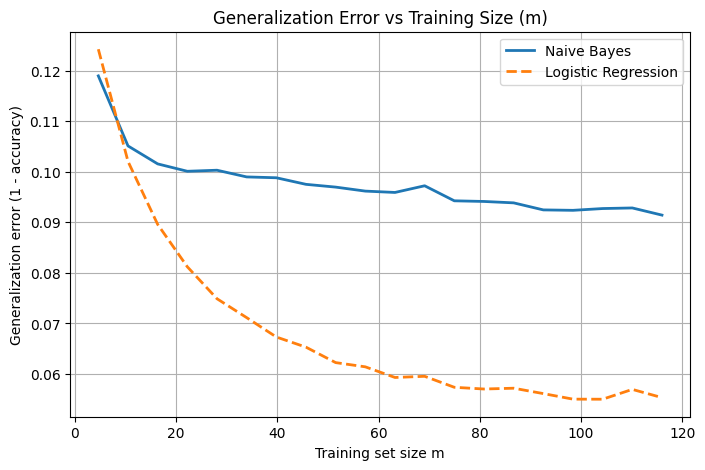

In [88]:
plot_learning_curves(m_values, scores_nbc, scores_lr)


In [65]:
df_breast = pd.read_csv("breast-cancer.csv")

n_init = len(df_breast)
# drop NAN values
df_voting = df_breast.dropna()

n_final = len(df_breast)
print(f"Initial number of rows: {n_init}")
print(f"Number of rows dropped: {n_init - n_final}")
print(f"Final number of rows: {n_final}")

Initial number of rows: 286
Number of rows dropped: 0
Final number of rows: 286


In [55]:
df_breast

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
...,...,...,...,...,...,...,...,...,...,...
281,recurrence-events,30-39,premeno,30-34,0-2,no,2,left,left_up,no
282,recurrence-events,30-39,premeno,20-24,0-2,no,3,left,left_up,yes
283,recurrence-events,60-69,ge40,20-24,0-2,no,1,right,left_up,no
284,recurrence-events,40-49,ge40,30-34,3-5,no,3,left,left_low,no


In [61]:
enc = LabelEncoder()
# fit a one-hot encoder and transform the labels
# (party is not ordinal)
y_cancer = enc.fit_transform(df_breast['Class'].to_numpy())

data_dummies = pd.get_dummies(
    df_breast, 
    columns=['menopause', 'breast', 'irradiat', 'breast-quad'])

cols = ['inv-nodes', 'node-caps', 'deg-malig','tumor-size','age']
enc = OrdinalEncoder()
enc.set_output(transform="pandas")

X_ord_df = enc.fit_transform(df_breast[cols])

# Drop original ordinal cols from dummies DF if they are still there
data_dummies = data_dummies.drop(columns=cols)

X_final = pd.concat([data_dummies, X_ord_df], axis=1)

X_final

,Class,menopause_ge40,menopause_lt40,menopause_premeno,breast_left,breast_right,irradiat_no,irradiat_yes,breast-quad_?,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,inv-nodes,node-caps,deg-malig,tumor-size,age
0,no-recurrence-events,False,False,True,True,False,True,False,False,False,True,False,False,False,0.0,1.0,2.0,5.0,1.0
1,no-recurrence-events,False,False,True,False,True,True,False,False,False,False,False,False,True,0.0,1.0,1.0,3.0,2.0
2,no-recurrence-events,False,False,True,True,False,True,False,False,False,True,False,False,False,0.0,1.0,1.0,3.0,2.0
3,no-recurrence-events,True,False,False,False,True,True,False,False,False,False,True,False,False,0.0,1.0,1.0,2.0,4.0
4,no-recurrence-events,False,False,True,False,True,True,False,False,False,False,False,True,False,0.0,1.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,recurrence-events,False,False,True,True,False,True,False,False,False,False,True,False,False,0.0,1.0,1.0,5.0,1.0
282,recurrence-events,False,False,True,True,False,False,True,False,False,False,True,False,False,0.0,1.0,2.0,3.0,1.0
283,recurrence-events,True,False,False,False,True,True,False,False,False,False,True,False,False,0.0,1.0,0.0,3.0,4.0
284,recurrence-events,True,False,False,True,False,True,False,False,False,True,False,False,False,4.0,1.0,2.0,5.0,2.0


In [90]:
scores_nbc, scores_lr, m_values = run_learning_curve_experiment(
    X_final,
    'Class',
    0.5,
    runs_per_m=1000
)

print("NBC:\n", scores_nbc)
print("LR:\n", scores_lr)
print("Training sizes:", m_values)

NBC:
 [[0.67083986 0.51342624]
 [0.66358759 0.57189753]
 [0.68762782 0.58821974]
 [0.69309266 0.5950838 ]
 [0.69891667 0.60229222]
 [0.69979184 0.60572708]
 [0.70116878 0.61344445]
 [0.7042913  0.61710969]
 [0.70769507 0.62207277]
 [0.70869444 0.62472182]
 [0.70927751 0.62557021]
 [0.71026866 0.62916693]
 [0.71068041 0.63043596]
 [0.71162032 0.63267295]
 [0.71401667 0.63622356]
 [0.71338372 0.6366196 ]
 [0.71478182 0.6397943 ]
 [0.71513291 0.64112636]
 [0.71460265 0.6408139 ]
 [0.7148042  0.64084445]]
LR:
 [[0.64950178 0.52097511]
 [0.61049635 0.54857081]
 [0.61751504 0.55065756]
 [0.62223552 0.55135626]
 [0.63555159 0.55899149]
 [0.6463551  0.56520964]
 [0.65814768 0.57393778]
 [0.66832174 0.58040942]
 [0.6786009  0.58876261]
 [0.68246296 0.59003808]
 [0.68621053 0.59018125]
 [0.69012935 0.59371424]
 [0.69442784 0.59649889]
 [0.69686631 0.5978436 ]
 [0.70006667 0.60159819]
 [0.70310465 0.60212825]
 [0.70544242 0.604402  ]
 [0.70677848 0.60388303]
 [0.7080596  0.60635589]
 [0.71094406 

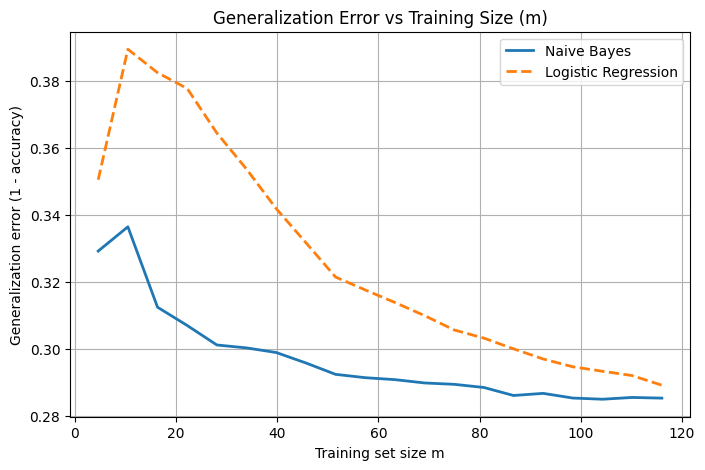

In [91]:
plot_learning_curves(m_values, scores_nbc, scores_lr)